In [5846]:
from models import *
from utilities import *

In [5847]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import copy
import math
import warnings
from scipy.stats import mannwhitneyu
warnings.filterwarnings('ignore')

In [5848]:
def remove_rows_within_n_days(data_copy: pd.DataFrame,
                             blood_trans: pd.DataFrame,
                             n: int) -> pd.DataFrame:
    # Make sure dates are datetime
    dc = data_copy.copy()
    dc['date'] = pd.to_datetime(dc['date'])
    bt = blood_trans.copy()
    bt['BloodTran_Start_DT'] = pd.to_datetime(bt['BloodTran_Start_DT'])

    # Keep original row index to identify rows later
    dc = dc.reset_index().rename(columns={'index': 'orig_idx'})

    # Merge to get all Start_DT for each SCCRIP_ID
    merged = dc.merge(bt[['id', 'BloodTran_Start_DT']], on='id', how='left')

    # Condition: Start_DT < date <= Start_DT + n days
    mask = (
        merged['BloodTran_Start_DT'].notna()
        & (merged['date'] > merged['BloodTran_Start_DT'])
        & (merged['date'] <= merged['BloodTran_Start_DT'] + pd.Timedelta(days=n))
    )

    # Find original rows that match the condition for ANY Start_DT
    bad_idx = merged.loc[mask, 'orig_idx'].unique()

    # Drop those rows from the original data_copy
    result = dc[~dc['orig_idx'].isin(bad_idx)].drop(columns='orig_idx')

    return result

def add_ctxn_flag(data_copy: pd.DataFrame,
                  ctxn: pd.DataFrame) -> pd.DataFrame:
    """
    Add a new column 'ctxn' to data_copy:
      ctxn = 1 if SCCRIP_ID in ctxn and date > CTXN_Start_DT1 (for that ID)
      ctxn = 0 otherwise.

    Assumes:
        - data_copy has ['SCCRIP_ID', 'date']
        - ctxn has ['SCCRIP_ID', 'CTXN_Start_DT1']
    """
    dc = data_copy.copy()
    cx = ctxn.copy()

    # Ensure datetime columns
    dc['date'] = pd.to_datetime(dc['date'])
    cx['CTXN_Start_DT1'] = pd.to_datetime(cx['CTXN_Start_DT1'])

    # Merge by SCCRIP_ID to attach CTXN_Start_DT1 to each data_copy row (if ID exists)
    merged = dc.merge(cx[['id', 'CTXN_Start_DT1']],
                      on='id', how='left')

    # Vectorized condition
    merged['ctxn'] = (
        (merged['CTXN_Start_DT1'].notna())
        & (merged['date'] > merged['CTXN_Start_DT1'])
    ).astype(int)

    # Drop the CTXN_Start_DT1 column if you don’t need it in the result
    merged = merged.drop(columns=['CTXN_Start_DT1'])

    return merged

In [5849]:
with open('../results/data/SCCRIP_ID_dict.pkl', 'rb') as f:
    mapping_dict = pickle.load(f)

In [5850]:
ctxn = read_sas('../data/Apply_MI_Zheng_2023_01/ctxn.sas7bdat')
ctxn['id'] = ctxn['SCCRIP_ID'].map(mapping_dict)
ctxn = ctxn[~ctxn['id'].isnull()]
ctxn = ctxn[['id',	'CTXN_Start_DT1']]
blood_trans = read_sas('../data/Apply_MI_Zheng_2023_01/bloodtrans_final.sas7bdat')
blood_trans['id'] = blood_trans['SCCRIP_ID'].map(mapping_dict)
blood_trans = blood_trans[~blood_trans['id'].isnull()]
blood_trans = blood_trans[['id',	'BloodTran_Start_DT']]

In [5851]:
df_all = pd.read_pickle('../results/data/all_treat_control_prediction_loop.pkl')

In [5852]:
df_hu = df_all[(df_all['hus'] > 0) & (df_all['hus'] < 100)]
# df_hu = df_all[(df_all['hus'] > 0)]

In [5853]:
df_hu.shape

(20344, 7)

In [5854]:
data_filter = remove_rows_within_n_days(df_hu, blood_trans, n = 30)
data_flag = add_ctxn_flag(data_filter, ctxn)

In [5855]:
HU_all_c = data_flag[data_flag['ctxn']==0]

In [5856]:
######################################################################

In [5857]:
HU_all_c['err_t'] = HU_all_c['pred_t'] - HU_all_c['pred_c']
HU_all_c['err_c'] = HU_all_c['test'] - HU_all_c['pred_c']

In [5858]:
######################

In [5859]:
df_hus = HU_all_c[['id', 'age', 'hus','test', 'err_c','err_t', 'date']]

In [5860]:
df_for_gee = copy.deepcopy(df_hus)

In [5861]:
hos = read_sas('../data/Apply_MI_Zheng_2023_01/edhosp.sas7bdat')
hos['VisitDate'] = pd.to_datetime(hos['VisitDate'])
hos['ID'] = hos['SCCRIP_ID'].map(mapping_dict)

In [5862]:
hos = hos[hos['Fin_VisitType'] == b'Inpatient']
hos = hos[['ID', 'VisitDate', 'DischargeDate', 'Stay_days']]
hos = hos.fillna(0)

In [5863]:
df_hos = copy.deepcopy(hos)

In [5864]:
d_windows, n_windows, n_per_year = 90, 24, 4

In [5865]:
def get_final_rows(t_df, t_hos, n,ids,d_windows=d_windows):
    df = pd.DataFrame(columns = ['n', 'id','age', 'date', 'hbf', 'err', 'err_t', 'hos_days'])
    
    s = t_df['date'].min()    
    for i in range(n):
        s0 = s
        s = s + pd.Timedelta(days=d_windows)
        t = t_df[(t_df['date'] >= s0) & (t_df['date'] <= s)]
        h = t_hos[(t_hos['VisitDate'] >= s0) & (t_hos['VisitDate'] <= s)]
        if len(t) > 0:
            hbf = t['test'].mean()
            err = t['err_c'].mean()
            err_t = t['err_t'].mean()

            date = s0
            age = t.iloc[0]['age']
            hos_d = h['Stay_days'].sum()
            
            df.loc[len(df)] = copy.deepcopy([i, ids, age, date, hbf, err, err_t, hos_d])
            
    return df

In [5866]:
# def get_final_rows(t_df, t_hos, n, ids, d_windows=d_windows):
#     df = pd.DataFrame(columns=['n', 'id','age', 'date', 'hbf', 'err', 'err_t',
#                                'hos_days'])

#     # Ensure sorted so "last value" is meaningful
#     t_df = t_df.sort_values('date')
#     t_hos = t_hos.sort_values('VisitDate')

#     s = t_df['date'].min()

#     last_hbf = np.nan
#     last_err = np.nan
#     last_err_t = np.nan
#     last_age = np.nan

#     for i in range(n):
#         s0 = s
#         s = s + pd.Timedelta(days=d_windows)

#         t = t_df[(t_df['date'] >= s0) & (t_df['date'] <= s)]
#         h = t_hos[(t_hos['VisitDate'] >= s0) & (t_hos['VisitDate'] <= s)]

#         # Hospital-derived fields (0 if no rows, since sum() on empty is 0)
#         hos_d = h['Stay_days'].sum()

#         date = s0

#         if len(t) > 0:
#             hbf = t['test'].mean()
#             err = t['err_c'].mean()
#             err_t = t['err_t'].mean()
#             age = t.iloc[0]['age']

#             # hbf, err, err_t, age = t.iloc[0]['test'], t.iloc[0]['err_c'], t.iloc[0]['err_t'], t.iloc[0]['age']
#             # update last seen values
#             last_hbf, last_err, last_err_t, last_age = t.iloc[-1]['test'], t.iloc[-1]['err_c'], t.iloc[-1]['err_t'], t.iloc[-1]['age']
#             # last_hbf, last_err, last_err_t, last_age = hbf, err, err_t, age
#         else:
#             # use last value if window is empty
#             hbf, err, err_t = last_hbf, last_err, last_err_t
#             age = last_age

#         df.loc[len(df)] = copy.deepcopy([i, ids, age, date, hbf, err, err_t, hos_d])

#     return df

In [5867]:
len(df_for_gee.id.unique())

575

In [5868]:
df_for_gee.shape

(14741, 7)

In [5869]:
df_for_gee['age'] = df_for_gee['age'].astype('float')

In [5870]:
df_for_gee.age.max(), df_for_gee.age.min()

(61.27310061601643, 0.7227926078028748)

In [5871]:
id_list = set(df_hos.ID).intersection(set(df_for_gee.id))
                        
df_list = []
for i in id_list:
    t_hos = df_hos[df_hos['ID'] == i]
    t_df = df_for_gee[df_for_gee['id'] == i]
    t_df = t_df.sort_values(by='date')
    t_hos = t_hos.sort_values(by='VisitDate')
               
    n_win = min((t_df['date'].max() - t_df['date'].min()).days//d_windows, n_windows)
    n_win = (n_win//n_per_year)*n_per_year

    df_ = get_final_rows(t_df=t_df, t_hos=t_hos, n=n_win,ids=i,d_windows=d_windows)
    df_list.append(copy.deepcopy(df_))

In [5872]:
df_all = pd.concat(df_list)

In [5873]:
df_all = df_all.fillna(0)

In [5874]:
df_all = df_all.sort_values(by=['id', 'n'])
df_all

,n,id,age,date,hbf,err,err_t,hos_days
0,0,0,5.45106092,2014-10-20,32.34999847,16.93752098,14.27817631,2.00000000
1,1,0,5.71937029,2015-01-18,37.00000000,17.54889297,14.63216305,2.00000000
2,2,0,6.06433949,2015-04-18,39.40000153,17.04808807,13.71065140,0.00000000
3,3,0,6.20670773,2015-07-17,41.30000305,15.71656513,13.87685490,0.00000000
4,4,0,6.60917180,2015-10-15,35.50000000,11.86893272,14.70937538,2.00000000
...,...,...,...,...,...,...,...,...
2,6,724,21.24845996,2019-07-30,17.39999962,14.90599155,11.40812778,0.00000000
3,10,724,22.31622177,2020-07-24,5.30000019,0.79953194,12.71585178,0.00000000
0,0,726,10.15468857,2016-07-05,8.39999962,7.54908133,9.11921787,0.00000000
1,3,726,11.07460643,2017-04-01,7.00000000,5.67151785,9.64663029,0.00000000


In [5875]:
df_all.min(), df_all.max()

(n                             0
 id                            0
 age                  0.72279261
 date        2002-05-14 00:00:00
 hbf                  0.40000001
 err                 -7.93585777
 err_t               -3.23160148
 hos_days             0.00000000
 dtype: object,
 n                            23
 id                          726
 age                 61.02395619
 date        2021-08-30 00:00:00
 hbf                 66.50000000
 err                 62.89734650
 err_t               31.05429649
 hos_days            39.00000000
 dtype: object)

In [5876]:
hbf_d = pd.DataFrame(columns=['cutoff','mean hos/py of 0','mean hos/py of 1','#py of 0','#py of 1'])
err_d = pd.DataFrame(columns=['cutoff','mean hos/py of 0','mean hos/py of 1','#py of 0','#py of 1'])
errT_d = pd.DataFrame(columns=['cutoff','mean hos/py of 0','mean hos/py of 1','#py of 0','#py of 1'])


v_range = [3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]

for i in v_range:
    dff = copy.deepcopy(df_all)
    dff["c_h"] = dff["hbf"].map(lambda x: 1 if x >= i else 0)
    dff["c_e"] = dff["err"].map(lambda x: 1 if x >= i else 0)
    dff["c_et"] = dff["err_t"].map(lambda x: 1 if x >= i else 0)
    
   
    mean_by_h2 = dff.groupby('c_h')['hos_days'].mean()*n_per_year
    count_by_h2 = dff.groupby('c_h')['hos_days'].count()/n_per_year
    hbf_d.loc[len(hbf_d)] = [i, mean_by_h2[0], mean_by_h2[1], count_by_h2[0], count_by_h2[1]]
    
    mean_by_e2 = dff.groupby('c_e')['hos_days'].mean()*n_per_year
    count_by_e2 = dff.groupby('c_e')['hos_days'].count()/n_per_year
    err_d.loc[len(err_d)] = [i, mean_by_e2[0], mean_by_e2[1], count_by_e2[0], count_by_e2[1]]

    mean_by_et2 = dff.groupby('c_et')['hos_days'].mean()*n_per_year 
    count_by_et2 = dff.groupby('c_et')['hos_days'].count()/n_per_year
    errT_d.loc[len(errT_d)] = [i, mean_by_et2[0], mean_by_et2[1], count_by_et2[0], count_by_et2[1]]

In [5892]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial,Poisson,NegativeBinomial
pd.set_option('display.float_format', '{:.8f}'.format)

In [5893]:
p_ch_d = []
p_ce_d = []
p_ceT_d = []
# for i in range(3, 30, 3):

cov_struct = sm.cov_struct.Exchangeable()
# cov_struct = sm.cov_struct.Autoregressive()
family=Poisson()
# family = NegativeBinomial()

for i in v_range:
    dff = copy.deepcopy(df_all)
    dff["c_h"] = dff["hbf"].map(lambda x: 1 if x >= i else 0)
    dff["c_e"] = dff["err"].map(lambda x: 1 if x >= i else 0)
    dff["c_et"] = dff["err_t"].map(lambda x: 1 if x >= i else 0)

    y = dff['hos_days']
    X1 = sm.add_constant(dff['c_h'])
    model1 = GEE(y, X1, groups=dff['id'], cov_struct=cov_struct,family=family)
    result1 = model1.fit()
    p_ch_d.append(result1.pvalues.c_h)
    
    X2 = sm.add_constant(dff['c_e'])
    model2 = GEE(y, X2, groups=dff['id'], cov_struct=cov_struct,family=family)
    result2 = model2.fit()
    p_ce_d.append(result2.pvalues.c_e)
    
    X3 = sm.add_constant(dff['c_et'])
    model3 = GEE(y, X3, groups=dff['id'], cov_struct=cov_struct,family=family)
    result3 = model3.fit()
    p_ceT_d.append(result3.pvalues.c_et)
    




hbf_d['p-val'] = p_ch_d
err_d['p-val'] = p_ce_d
errT_d['p-val'] = p_ceT_d

In [5894]:
hbf_d.loc[hbf_d['p-val'].idxmin()]

cutoff              19.00000000
mean hos/py of 0     0.73735726
mean hos/py of 1     0.32084993
#py of 0           766.25000000
#py of 1           941.25000000
p-val                0.00001518
Name: 16, dtype: float64

In [5895]:
err_d.loc[err_d['p-val'].idxmin()]

cutoff               9.00000000
mean hos/py of 0     0.74408754
mean hos/py of 1     0.34025519
#py of 0           708.25000000
#py of 1           999.25000000
p-val                0.00000133
Name: 6, dtype: float64

In [5896]:
errT_d.loc[errT_d['p-val'].idxmin()]

cutoff               12.00000000
mean hos/py of 0      0.62364532
mean hos/py of 1      0.33790614
#py of 0           1015.00000000
#py of 1            692.50000000
p-val                 0.00093706
Name: 9, dtype: float64

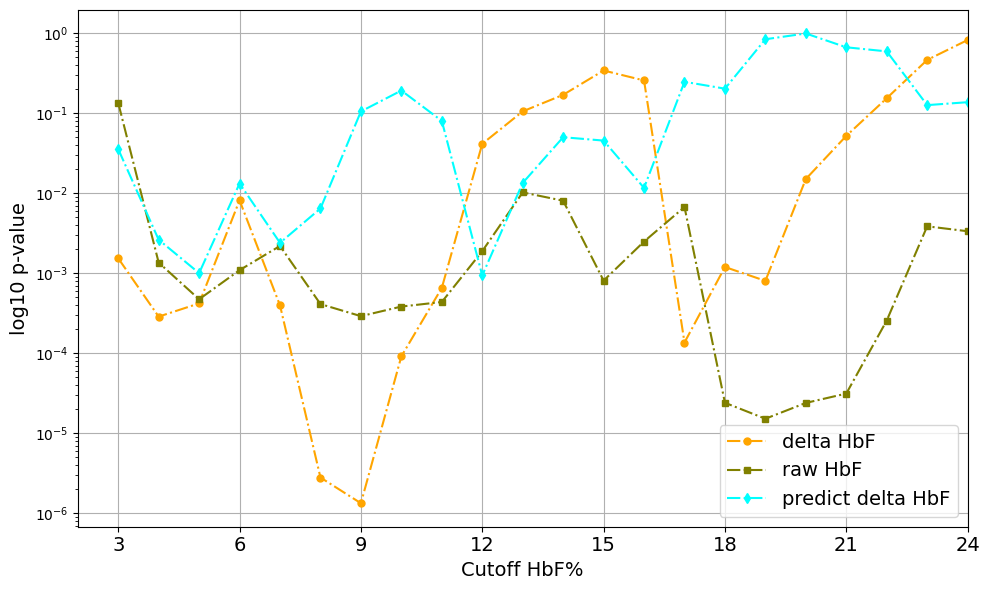

In [5897]:
plt.figure(figsize=(10, 6))

plt.plot(err_d['cutoff'], err_d['p-val'], linestyle='-.',marker='o', color='orange', markersize=5, label='delta HbF')
plt.plot(hbf_d['cutoff'], hbf_d['p-val'], linestyle='-.',marker='s', color='olive', markersize=5, label='raw HbF')
plt.plot(errT_d['cutoff'], errT_d['p-val'], linestyle='-.',marker='d', color='cyan', markersize=5, label='predict delta HbF')
plt.xlim([2, 24])
plt.yscale('log')
plt.xticks(np.arange(3, 25, 3), fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.xlabel('Cutoff HbF%', fontsize=14)
plt.ylabel('log10 p-value', fontsize=14)
plt.tight_layout()

In [5898]:
cov_struct = sm.cov_struct.Exchangeable()
dff = copy.deepcopy(df_all)
dff["c_h"] = dff["hbf"].map(lambda x: 1 if x < 19 else 0)
dff["c_e"] = dff["err"].map(lambda x: 1 if x < 9 else 0)
dff["c_et"] = dff["err_t"].map(lambda x: 1 if x < 12 else 0)

y = dff['hos_days']

X1 = sm.add_constant(dff['c_h'])
model1 = GEE(y, X1, groups=dff['id'],cov_struct=cov_struct, family=family)
result1x = model1.fit()

X2 = sm.add_constant(dff['c_e'])
model2 = GEE(y, X2, groups=dff['id'],cov_struct=cov_struct, family=family)
result2x = model2.fit()

X3 = sm.add_constant(dff['c_et'])
model3 = GEE(y, X3, groups=dff['id'],cov_struct=cov_struct, family=family)
result3x = model3.fit()

In [5899]:
coef1 = result1x.params
se1 = result1x.bse
odds_ratios1 = np.exp(coef1)
ci_lower1 = np.exp(coef1 - 1.96 * se1)
ci_upper1 = np.exp(coef1 + 1.96 * se1)

coef2 = result2x.params
se2 = result2x.bse
odds_ratios2 = np.exp(coef2)
ci_lower2 = np.exp(coef2 - 1.96 * se2)
ci_upper2 = np.exp(coef2 + 1.96 * se2)

coef3 = result3x.params
se3 = result3x.bse
odds_ratios3 = np.exp(coef3)
ci_lower3 = np.exp(coef3 - 1.96 * se3)
ci_upper3 = np.exp(coef3 + 1.96 * se3)

In [5900]:
gee_results1 = pd.DataFrame({
    "Variable": result1x.params.index,
    "Odds Ratio": odds_ratios1,
    "Lower 95% CI": ci_lower1,
    "Upper 95% CI": ci_upper1,
    "p-value": result1x.pvalues
})

In [5901]:
gee_results1

,Variable,Odds Ratio,Lower 95% CI,Upper 95% CI,p-value
const,const,0.09070021,0.06214845,0.13236900,0.00000000
c_h,c_h,2.35946043,1.59921142,3.48112416,0.00001518


In [5902]:
gee_results2 = pd.DataFrame({
    "Variable": result2x.params.index,
    "Odds Ratio": odds_ratios2,
    "Lower 95% CI": ci_lower2,
    "Upper 95% CI": ci_upper2,
    "p-value": result2x.pvalues
})

In [5903]:
gee_results2

,Variable,Odds Ratio,Lower 95% CI,Upper 95% CI,p-value
const,const,0.09281649,0.06429182,0.13399685,0.00000000
c_e,c_e,2.41918536,1.69094462,3.46105822,0.00000133


In [5904]:
gee_results3 = pd.DataFrame({
    "Variable": result3x.params.index,
    "Odds Ratio": odds_ratios3,
    "Lower 95% CI": ci_lower3,
    "Upper 95% CI": ci_upper3,
    "p-value": result3x.pvalues 
})

In [5905]:
gee_results3

,Variable,Odds Ratio,Lower 95% CI,Upper 95% CI,p-value
const,const,0.09269133,0.06519699,0.13178037,0.00000000
c_et,c_et,1.98498579,1.32244123,2.97946594,0.00093706


In [5906]:
36*3

108